# Post mofa-flex analysis

### Contents:

1. [Load models (Normal, SnS, and GP).](#load-models)

2. [MOFA-Flex model result overview.](#mofa-flex-results-overview)
<br>
2.1 [Factor correlation and variance explained.](#1-variance-explained)
<br>
2.2 [Average R2.](#2-average-r2)
<br>
2.3 [Weights distribution.](#3weights-dist)
<br>
2.4 [Heatmap (view x LR).](#4-heatmap-view-x-lr)

3. [DR and clustering.](#dr-using-factors-values)

4. [Regression Model.](#regression-model)
<br>
4.1 [Evaluate model.](#evaluate-the-model)
<br>
4.2 [AUC.](#auc)

5. [Map clusters to spatial.](#map-clusters-to-spatial)

In [1]:
import os.path
import anndata as ad
import mudata as md
import numpy as np
import pandas as pd
import mofaflex as mfl
from plotnine import *
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from umap import UMAP
from sklearn.manifold import TSNE

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



# Run MOFA

## Read mdata

In [80]:
mdata_path = Path("/g/stegle/aalsayah/repos/data/slidatag/slidetags/mudata")

In [81]:
mdata = md.read(mdata_path / "SCP2170_wide_anno.h5mu")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [83]:
mdata

MuData object with n_obs × n_vars = 4584 × 2875
  var:	'n_cells'
  6 modalities
    Choroid_Plexus:	141 x 304
      obs:	'X', 'Y', 'cell_type', 'n_genes', 'cell_type_lv1'
      var:	'n_cells'
      uns:	'CellChat', 'CellPhoneDB', 'Connectome', 'Geometric Mean', 'NATMI', 'Rank_Aggregate', 'SingleCellSignalR', 'cell_type_colors', 'cell_type_lv1_colors', 'global_score', 'log1p', 'log2FC', 'moranI', 'neighbors', 'pca', 'scSeqComm', 'umap'
      obsm:	'X_pca', 'X_umap', 'spatial'
      varm:	'PCs'
      layers:	'transformed'
      obsp:	'connectivities', 'distances', 'spatial_connectivities'
    Neuron:	4207 x 694
      obs:	'X', 'Y', 'cell_type', 'n_genes', 'cell_type_lv1'
      var:	'n_cells'
      uns:	'CellChat', 'CellPhoneDB', 'Connectome', 'Geometric Mean', 'NATMI', 'Rank_Aggregate', 'SingleCellSignalR', 'cell_type_colors', 'cell_type_lv1_colors', 'global_score', 'log1p', 'log2FC', 'moranI', 'neighbors', 'pca', 'scSeqComm', 'umap'
      obsm:	'X_pca', 'X_umap', 'spatial'
      varm:	'PCs'
      layers:	'transformed'
      obsp:	'connectivities', 'distances', 'spatial_connectivities'
    Glial:	1506 x 561
      obs:	'X', 'Y', 'cell_type', 'n_genes', 'cell_type_lv1'
      var:	'n_cells'
      uns:	'CellChat', 'CellPhoneDB', 'Connectome', 'Geometric Mean', 'NATMI', 'Rank_Aggregate', 'SingleCellSignalR', 'cell_type_colors', 'cell_type_lv1_colors', 'global_score', 'log1p', 'log2FC', 'moranI', 'neighbors', 'pca', 'scSeqComm', 'umap'
      obsm:	'X_pca', 'X_umap', 'spatial'
      varm:	'PCs'
      layers:	'transformed'
      obsp:	'connectivities', 'distances', 'spatial_connectivities'
    Endothelial:	919 x 524
      obs:	'X', 'Y', 'cell_type', 'n_genes', 'cell_type_lv1'
      var:	'n_cells'
      uns:	'CellChat', 'CellPhoneDB', 'Connectome', 'Geometric Mean', 'NATMI', 'Rank_Aggregate', 'SingleCellSignalR', 'cell_type_colors', 'cell_type_lv1_colors', 'global_score', 'log1p', 'log2FC', 'moranI', 'neighbors', 'pca', 'scSeqComm', 'umap'
      obsm:	'X_pca', 'X_umap', 'spatial'
      varm:	'PCs'
      layers:	'transformed'
      obsp:	'connectivities', 'distances', 'spatial_connectivities'
    Fibroblast:	825 x 642
      obs:	'X', 'Y', 'cell_type', 'n_genes', 'cell_type_lv1'
      var:	'n_cells'
      uns:	'CellChat', 'CellPhoneDB', 'Connectome', 'Geometric Mean', 'NATMI', 'Rank_Aggregate', 'SingleCellSignalR', 'cell_type_colors', 'cell_type_lv1_colors', 'global_score', 'log1p', 'log2FC', 'moranI', 'neighbors', 'pca', 'scSeqComm', 'umap'
      obsm:	'X_pca', 'X_umap', 'spatial'
      varm:	'PCs'
      layers:	'transformed'
      obsp:	'connectivities', 'distances', 'spatial_connectivities'
    Immune:	216 x 150
      obs:	'X', 'Y', 'cell_type', 'n_genes', 'cell_type_lv1'
      var:	'n_cells'
      uns:	'CellChat', 'CellPhoneDB', 'Connectome', 'Geometric Mean', 'NATMI', 'Rank_Aggregate', 'SingleCellSignalR', 'cell_type_colors', 'cell_type_lv1_colors', 'global_score', 'log1p', 'log2FC', 'moranI', 'neighbors', 'pca', 'scSeqComm', 'umap'
      obsm:	'X_pca', 'X_umap', 'spatial'
      varm:	'PCs'
      layers:	'transformed'
      obsp:	'connectivities', 'distances', 'spatial_connectivities'

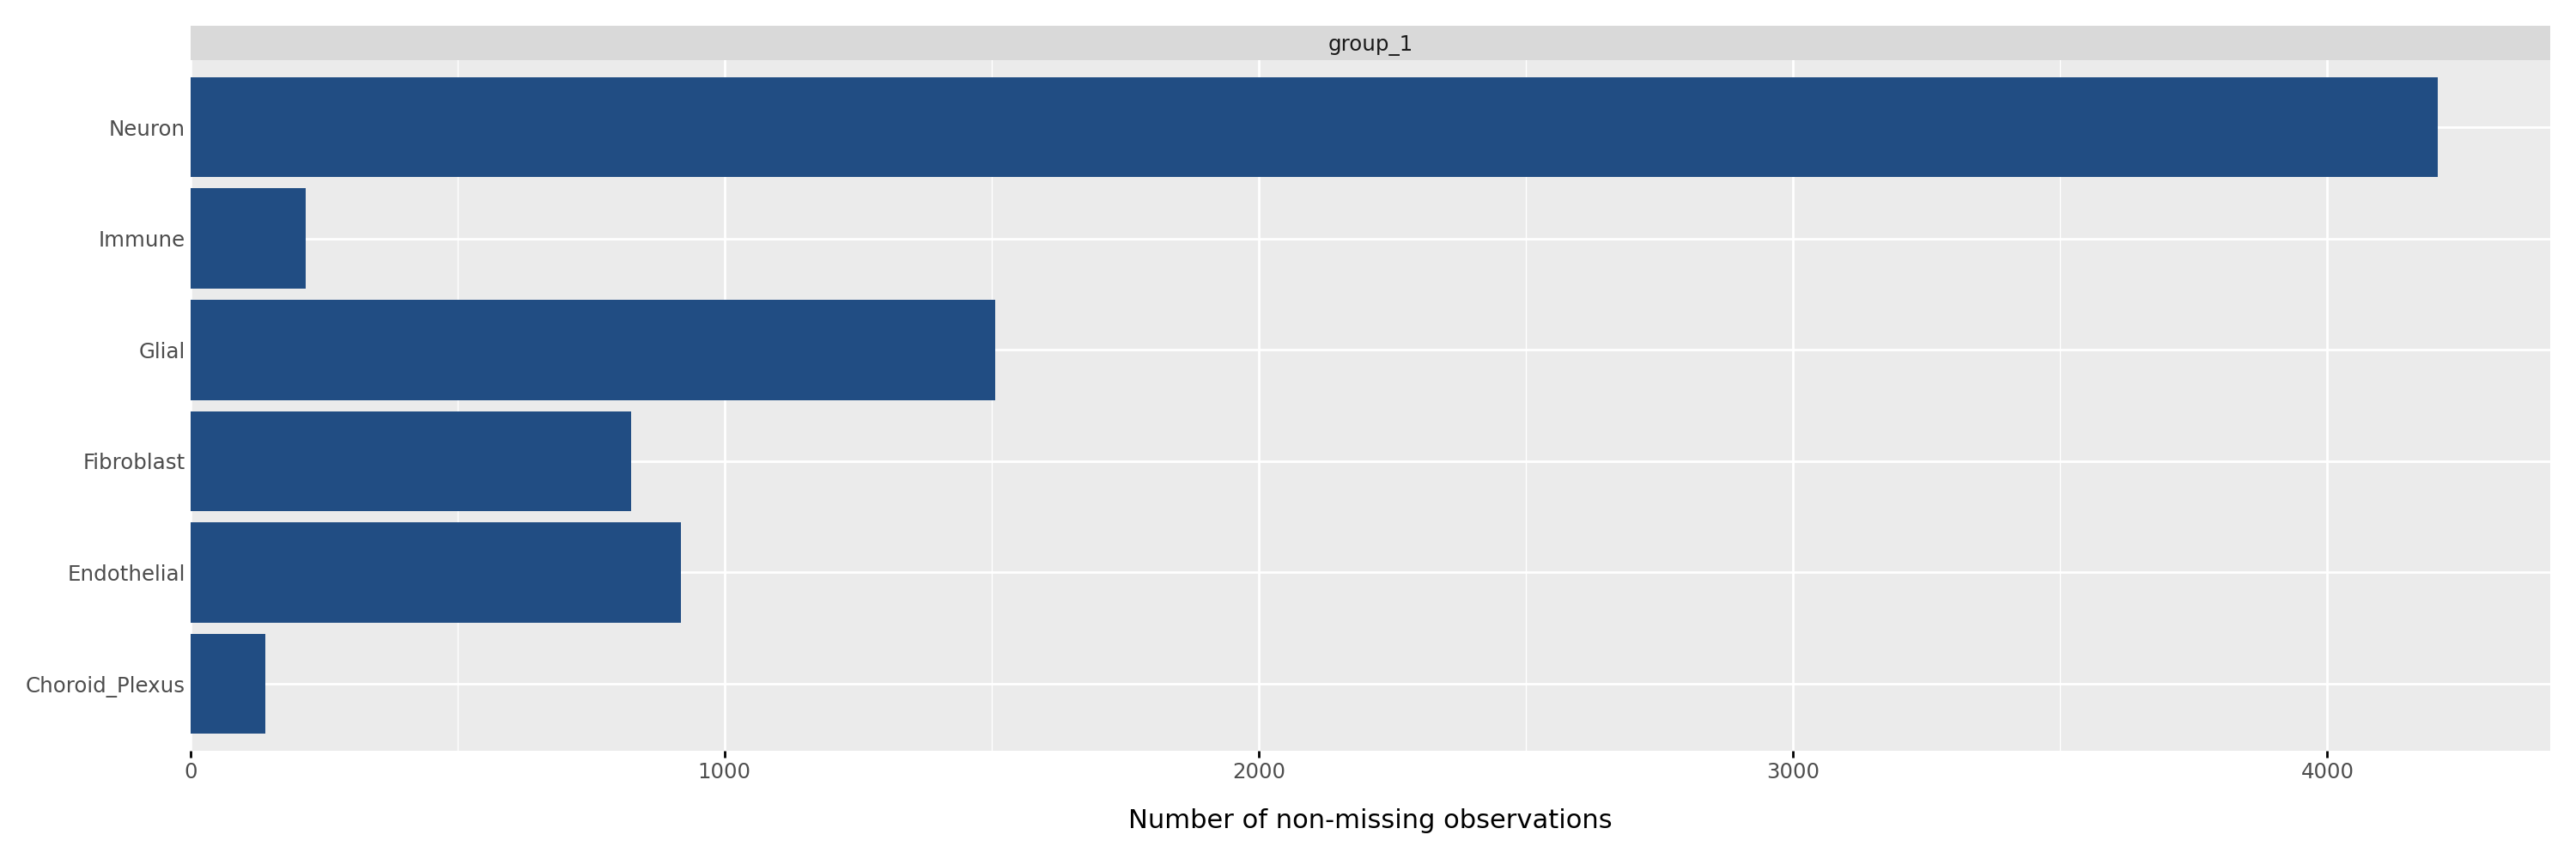

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default any

  0%|                                                                                                         …

INFO	Training converged after 538 epochs.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
INFO	Saving results to /g/stegle/aalsayah/repos/data/slidatag/slidetags/models/SCP2170_wide_anno_Normal_weight_model.hdf5...


In [130]:
model = mfl.MOFAFLEX(
    mdata,
    mfl.ModelOptions(
        n_factors=10,
        factor_prior="Normal",
        likelihoods="Normal",
        weight_prior="Normal",
    ),
    mfl.TrainingOptions(
        batch_size=2000,
        n_particles=10,
        lr=0.005,
        max_epochs=1000,
        save_path=str("/g/stegle/aalsayah/repos/data/slidatag/slidetags/models/SCP2170_wide_anno_Normal_weight_model.hdf5"),
        early_stopper_patience=50,
    ),
)

# Load models

### Normal

In [9]:
models_path = Path("/g/stegle/aalsayah/repos/data/slidatag/slidetags/models")

In [10]:
model= mfl.MOFAFLEX.load(models_path / 'SCP2170_normal_model.hdf5')

### SnS

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "sns_models/crc_110/Normal.SnS/crc_110.Normal.SnS.hdf5")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


### GP

In [ ]:
#model = mfl.MOFAFLEX.load(models_path / "GP_models/crc_232_no_mye_IgM/GP.Normal/crc_232_no_mye_IgM.GP.Normal.hdf5")

# MOFA-Flex results overview

## 1. Variance Explained

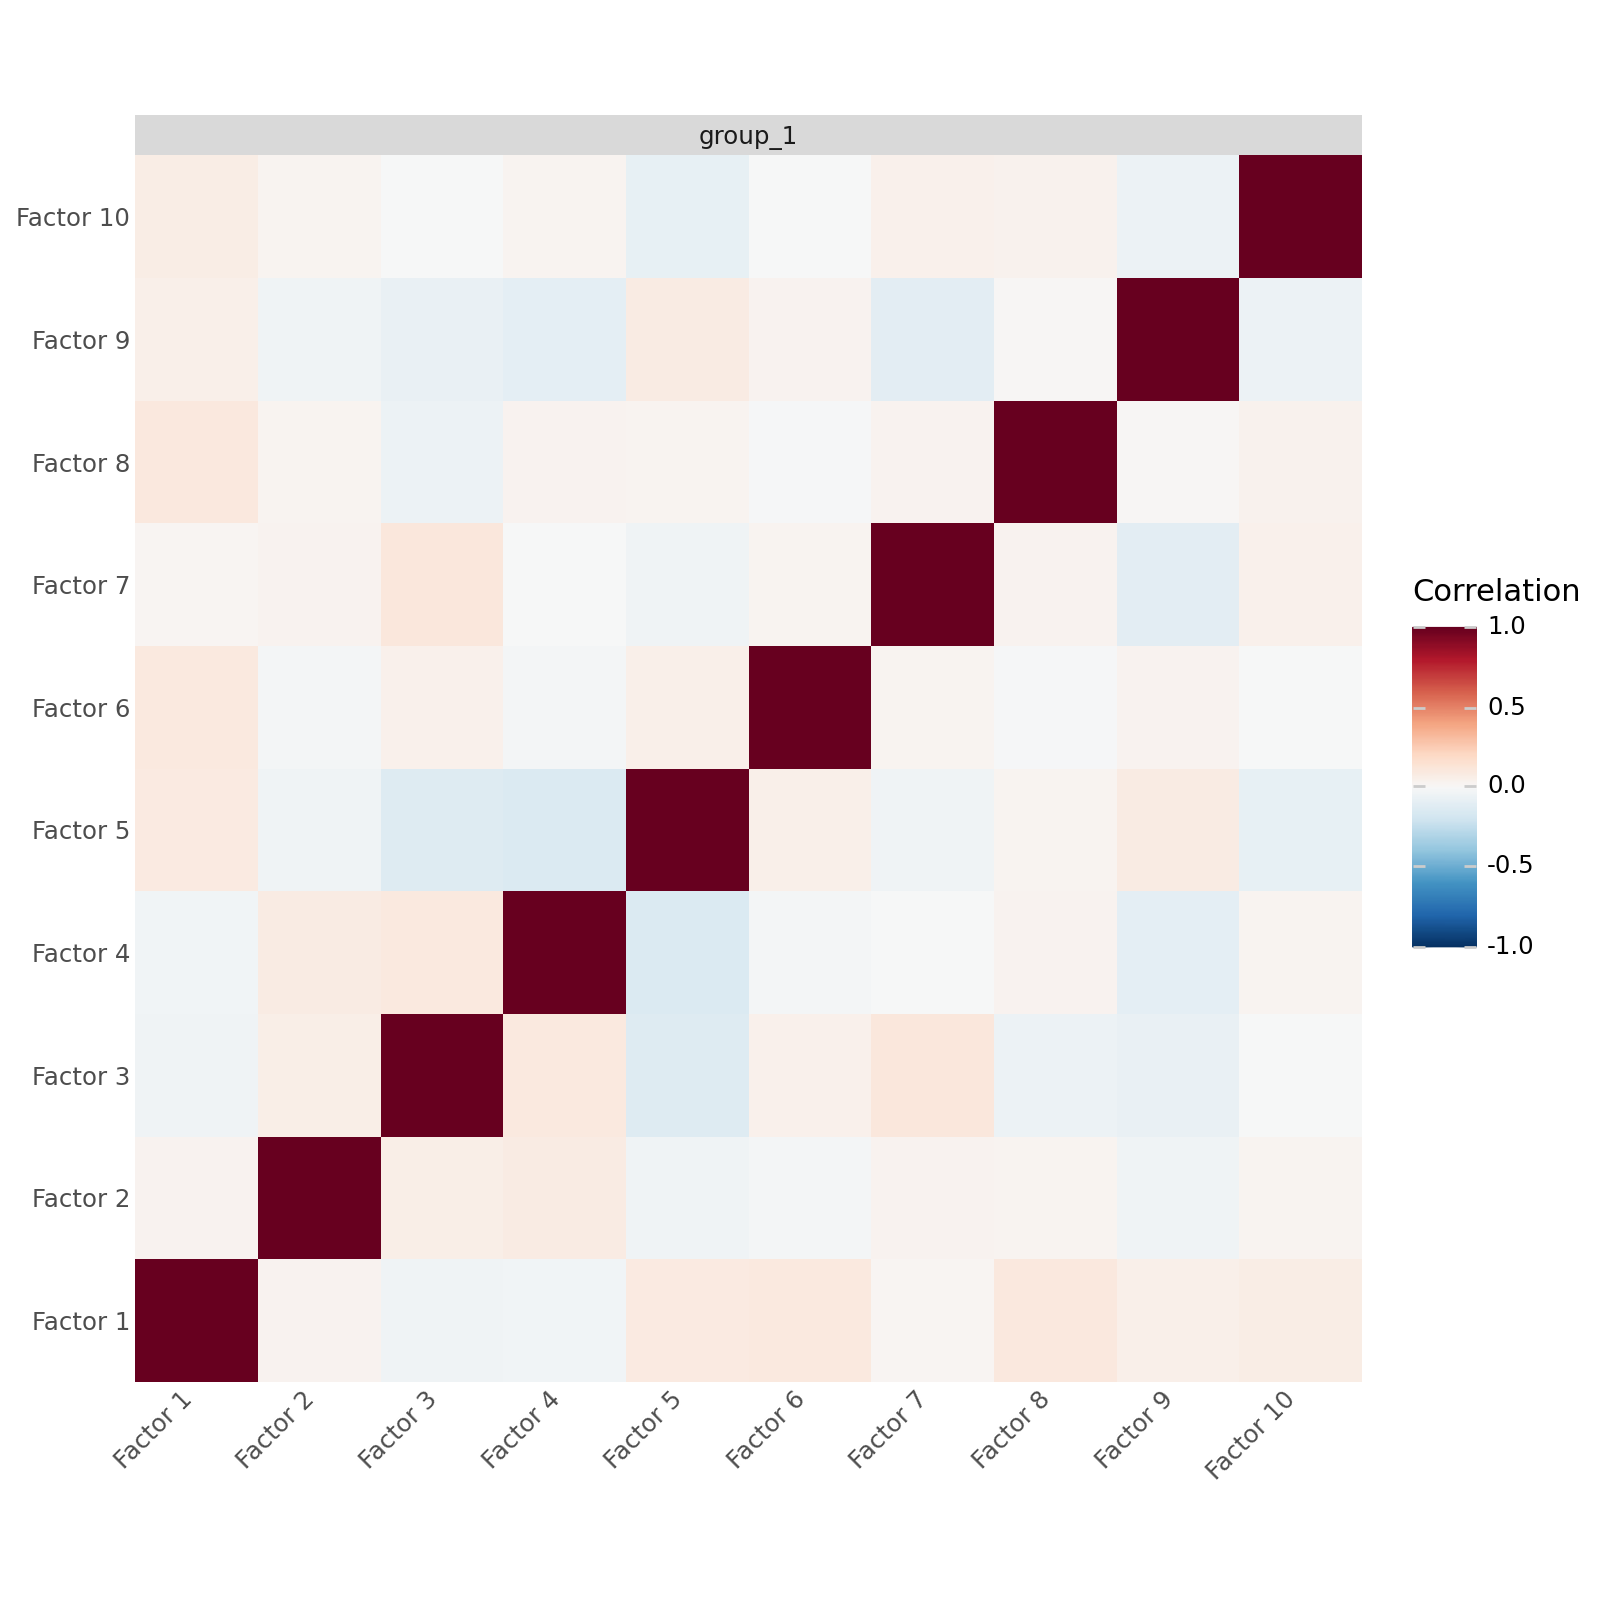

In [131]:
mfl.pl.factor_correlation(model)

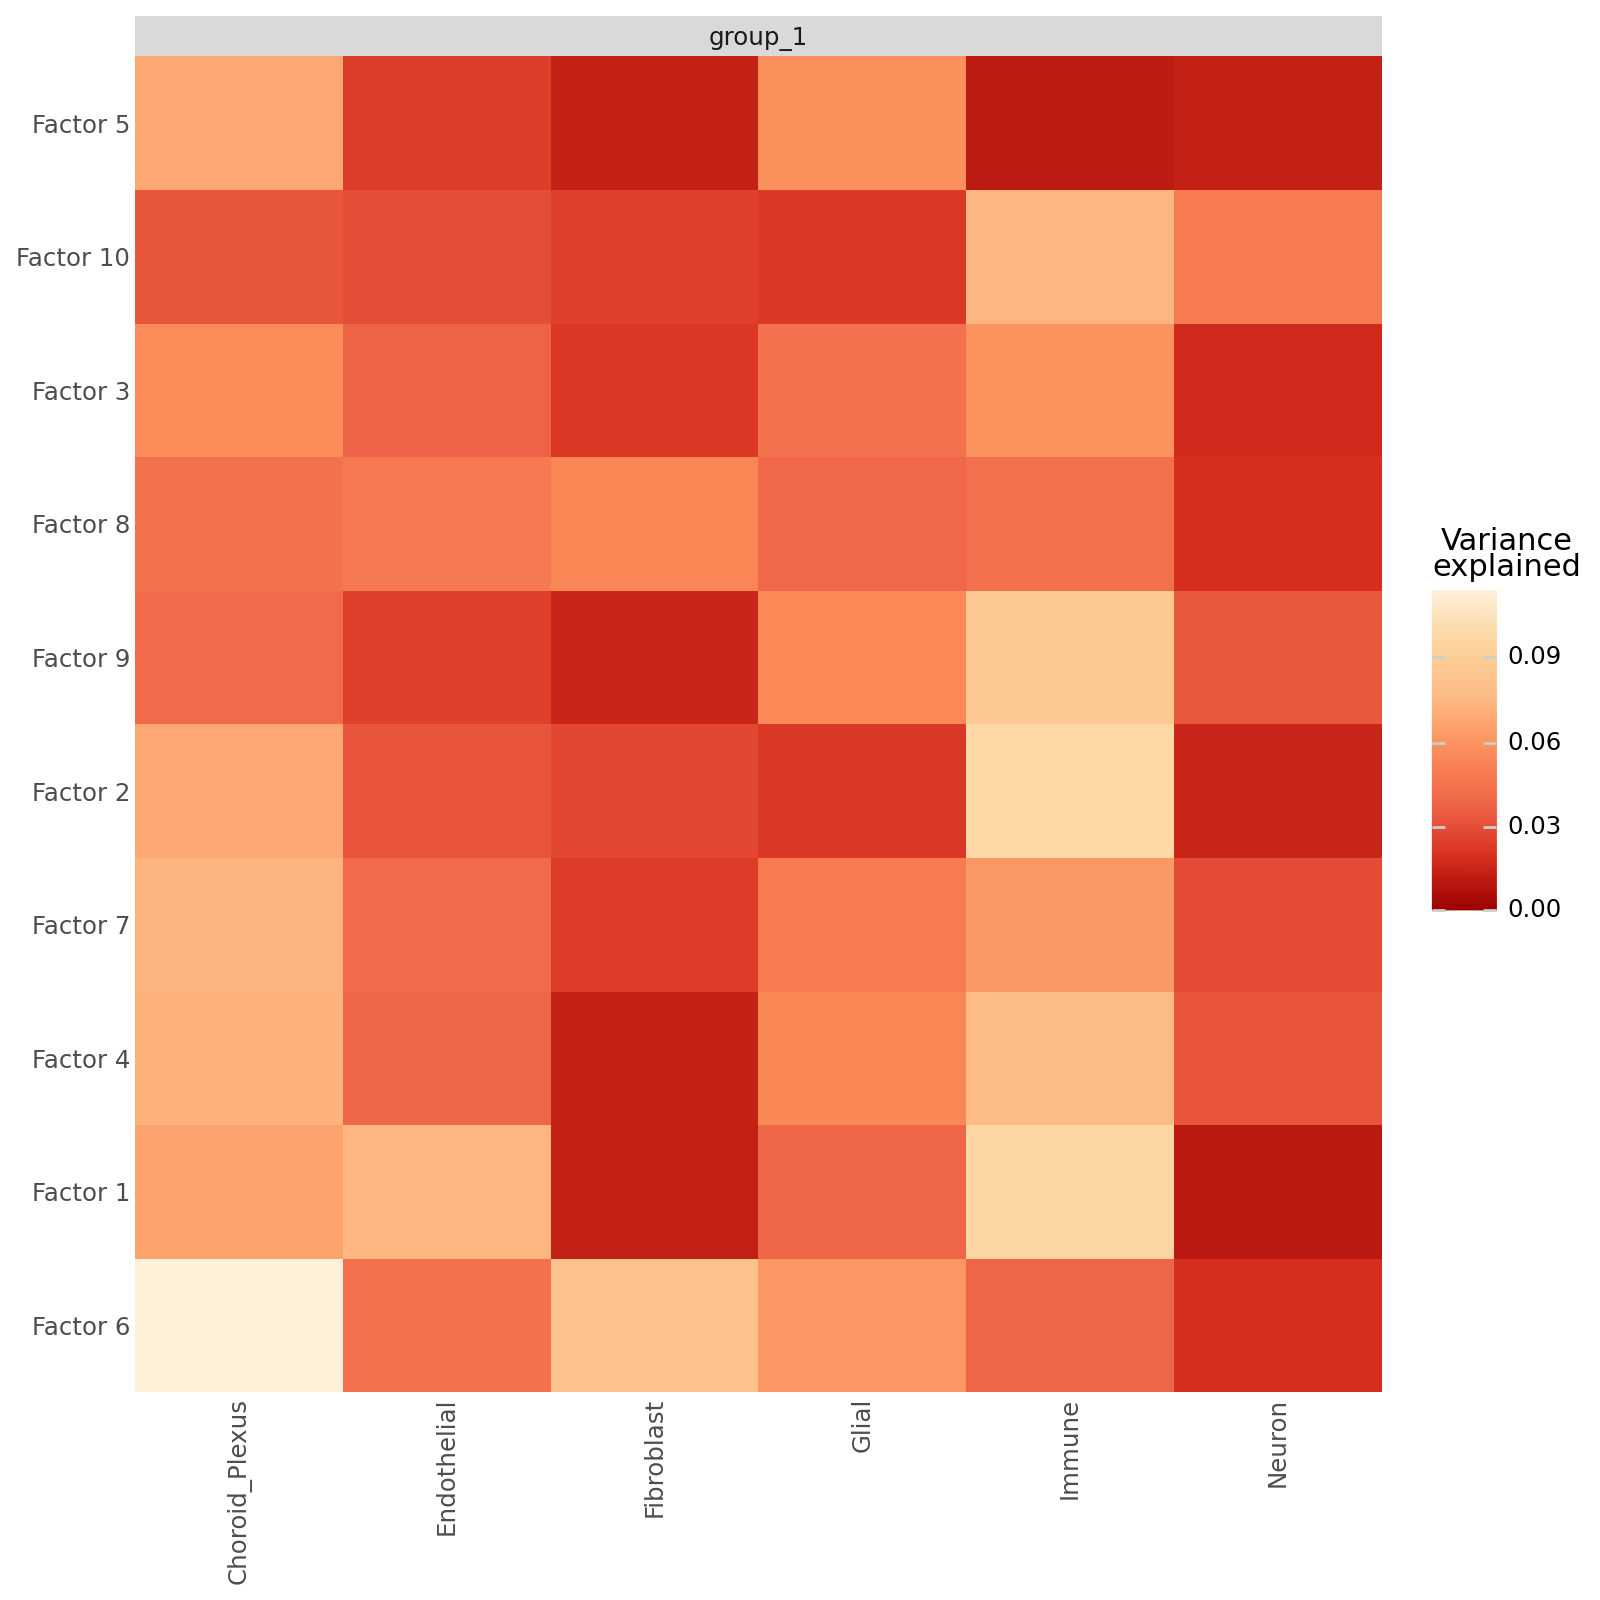

In [132]:
mfl.pl.variance_explained(model, figsize= (8,8))

## 2. Average R2

In [133]:
print(model.get_r2(total=True))

                 group_1
Choroid_Plexus  0.589573
Neuron          0.208348
Glial           0.354679
Endothelial     0.370075
Fibroblast      0.298578
Immune          0.650525


In [134]:
r2 = model.get_r2(total=True)
r2["group_1"].mean()

np.float64(0.41196274946237277)

## 3.Weights dist

In [89]:
weights_dict= model.get_weights()

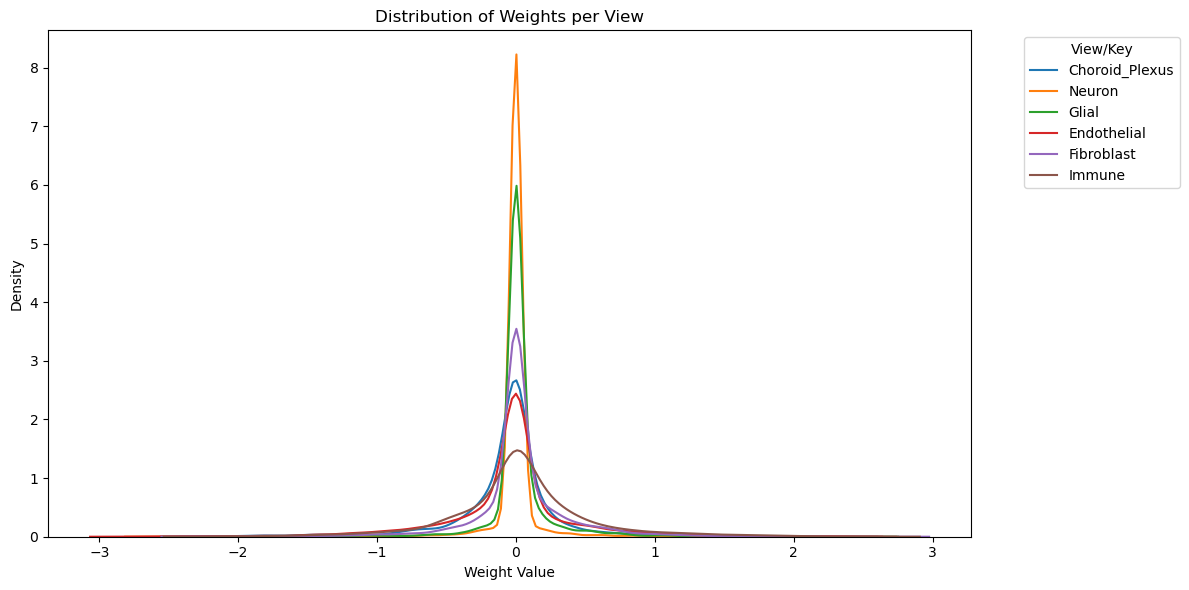

In [90]:
plt.figure(figsize=(12, 6))

# Loop through each view/key
for key, df in weights_dict.items():
    # Flatten all weights from that DataFrame into 1D array
    values = df.values.flatten()
    sns.kdeplot(values, label=key, fill=False)  # distribution curve

plt.title("Distribution of Weights per View")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend(title="View/Key", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
#mfl.pl.all_weights(model_gp, views=['fib2'], figsize=(8,8), show_featurenames=True)
#mfl.pl.weights(model, n_features=10, views=["fib2"], factors=1, pointsize=2, figsize=(8,8))
#mfl.pl.top_weights(model, n_features=15, views="fib2", factors=1)

## 4. Heatmap (view x LR)

In [17]:
from string import ascii_uppercase
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [18]:
weights = model.get_weights()

In [19]:
import re
from matplotlib.colors import TwoSlopeNorm

# choose the factor you want:
factor = 12

def resolve_factor_label(df, factor):
    """
    Return the exact row label in df.index for a given factor selector.
    Accepts: 3, "3", "Factor 3", "factor 03", etc.
    """
    idx_map = {str(idx).strip().lower(): idx for idx in df.index}
    key = str(factor).strip().lower()
    # exact match first
    if key in idx_map:
        return idx_map[key]
    # otherwise pull the first integer and try "Factor {n}"
    m = re.search(r'\d+', key)
    if m:
        candidate = f"factor {int(m.group())}"
        if candidate in idx_map:
            return idx_map[candidate]
    raise KeyError(f"Couldn't find factor '{factor}'. Available: {list(df.index)}")

rows, labels = [], []
for view, df in weights.items():
    row_label = resolve_factor_label(df, factor)
    s = df.loc[row_label].copy()
    s.index = ['^'.join(c.split('^')[1:]) for c in s.index]  # drop prefix before first ^
    rows.append(s)
    labels.append(view)

# assemble matrix (align columns across views)
all_cols = sorted({c for s in rows for c in s.index})
X = pd.DataFrame([s.reindex(all_cols) for s in rows], index=labels)

plt.figure(figsize=(0.5*X.shape[1] + 2, 0.6*X.shape[0] + 1))

# zero-centered diverging colormap
v = np.nanmax(np.abs(X.values))
norm = TwoSlopeNorm(vmin=-v, vcenter=0.0, vmax=v)
cmap = plt.get_cmap('coolwarm').copy()
cmap.set_bad('lightgray')  # NaNs

im = plt.imshow(np.ma.masked_invalid(X.values),
                aspect='auto', interpolation='nearest',
                cmap=cmap, norm=norm)

plt.yticks(range(X.shape[0]), X.index)
plt.xticks(range(X.shape[1]), X.columns, rotation=90)
plt.ylabel("view")
plt.colorbar(im, label="weight")
for r in range(1, X.shape[0]):
    plt.axhline(r - 0.5, color='black', lw=1)
plt.title(f"Factor {factor}", pad=10)  # shows "Factor 3" if you passed 3
plt.tight_layout()
plt.show()


# DR using factors values

In [91]:
factors = model.get_factors()
factors = factors["group_1"]

In [92]:
factors

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10
AAACGAACAGAGAGGG-1,0.336108,0.092483,0.224647,0.086267,0.205714,-0.217745,0.275992,0.036657,0.042658,0.018042
AAAGAACGTGGCCTCA-1,-2.261797,-0.907688,-0.482416,-0.278066,-0.001190,-0.852577,0.187817,-1.067852,0.883831,-0.955699
AAAGGTATCCAATGCA-1,0.224354,0.289845,0.198087,0.076538,0.027525,-0.057109,0.208068,0.044439,-0.043968,0.242644
AACAGGGCAAAGGTTA-1,0.235455,0.203706,0.156741,0.195118,0.098455,-0.262565,0.230485,0.011463,0.198196,0.134021
AACCTTTCAGAGTTCT-1,0.086785,-0.509846,-0.749059,-0.769909,-0.063598,0.564609,-0.179342,0.220247,1.280410,0.329950
...,...,...,...,...,...,...,...,...,...,...
TTTCACAGTCAAAGCG-1,0.527889,1.688887,-1.247722,0.467618,-1.739061,0.221997,-0.692754,0.639492,1.097599,0.954408
TTTCAGTGTACACGCC-1,-0.007769,0.183602,0.184535,0.067804,-0.118818,-0.237732,0.146991,0.005299,0.654958,-0.198038
TTTCGATAGCCATGCC-1,0.793158,1.639569,0.362340,-0.878246,0.298999,-1.654063,-2.070898,-0.309584,1.527244,0.419525
TTTGGAGAGCCAACCC-1,0.784657,1.060429,-1.567523,-0.360292,-0.728661,0.124149,1.076372,0.044810,-0.270506,1.231883


### Load lrdata

In [93]:
data_path = Path("/g/stegle/aalsayah/repos/data/slidatag/slidetags/lrdata")
lrdata = sc.read_h5ad(data_path/ "SCP2170_wide_anno.h5ad")

In [94]:
lv1 = lrdata.obs["cell_type_lv1"]

In [95]:
lv1 = lv1.loc[lv1.index.intersection(factors.index)]
lv1 = lv1.reindex(factors.index)
lv1.shape

(4584,)

## UMAP

In [96]:
import umap.umap_ as umap
from sklearn.preprocessing import StandardScaler
import hdbscan

In [97]:
# --- Standardize ---
scaler = StandardScaler()
X = scaler.fit_transform(factors)

### higher-D

In [98]:
# --- UMAP for clustering (higher-D) ---
umap_clusters = umap.UMAP(
    n_components=10,
    n_neighbors=50,         
    min_dist=0.2,           
    metric="euclidean",      
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [99]:
# --- HDBSCAN: start conservative ---
n = X.shape[0]
mcs = max(30, int(np.sqrt(n)))  
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=None,               
    cluster_selection_method="eom",  
    cluster_selection_epsilon=0.05  
).fit(umap_clusters)

labels = clusterer.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_rate = (labels == -1).mean()
print(f"clusters={n_clusters}, noise={noise_rate:.2%}")

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


clusters=12, noise=52.51%


#### 2D UMAP

In [100]:
# --- 2D UMAP for visualization only ---
umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.2,
    metric="euclidean",
    random_state=42
).fit_transform(X)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


In [101]:
df_umap = pd.DataFrame(umap2, columns=['UMAP1','UMAP2'], index=factors.index)
df_umap['Cluster'] = labels
df_umap['Conf'] = clusterer.probabilities_  # how confident each assignment is

#### Plot UMAP

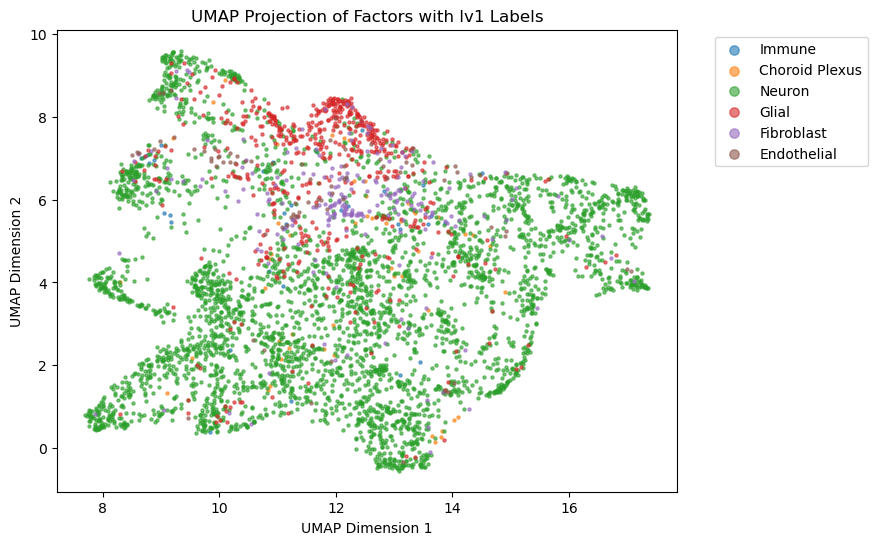

In [102]:
df_umap['Label'] = lv1.loc[factors.index].values

# Step 4: Plot UMAP with labels
plt.figure(figsize=(8,6))
for label in df_umap['Label'].unique():
    subset = df_umap[df_umap['Label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP Projection of Factors with lv1 Labels")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

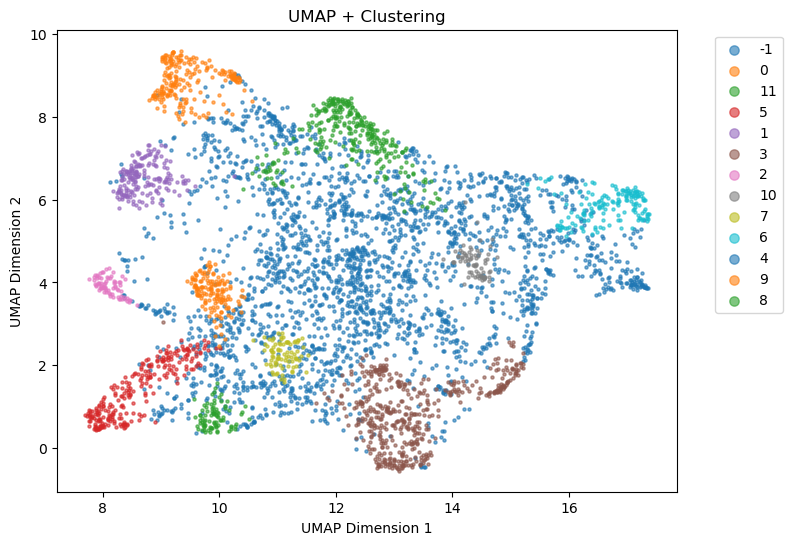

In [103]:
#Plot clusters

plt.figure(figsize=(8,6))
for label in df_umap['Cluster'].unique():
    subset = df_umap[df_umap['Cluster'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], s=5, alpha=0.6, label=label)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP + Clustering")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [104]:
df_umap['Cluster']

AAACGAACAGAGAGGG-1   -1
AAAGAACGTGGCCTCA-1   -1
AAAGGTATCCAATGCA-1   -1
AACAGGGCAAAGGTTA-1   -1
AACCTTTCAGAGTTCT-1   -1
                     ..
TTTCACAGTCAAAGCG-1   -1
TTTCAGTGTACACGCC-1   -1
TTTCGATAGCCATGCC-1   -1
TTTGGAGAGCCAACCC-1   -1
GCAGCTGAGGCTGTAG-1    5
Name: Cluster, Length: 4584, dtype: int64

In [105]:
lrdata.obs['Cluster'] = df_umap['Cluster'].reindex(lrdata.obs.index)

In [106]:
# Fill NaNs with default cluster value
lrdata.obs['Cluster'] = lrdata.obs['Cluster'].fillna(-1).astype(str)

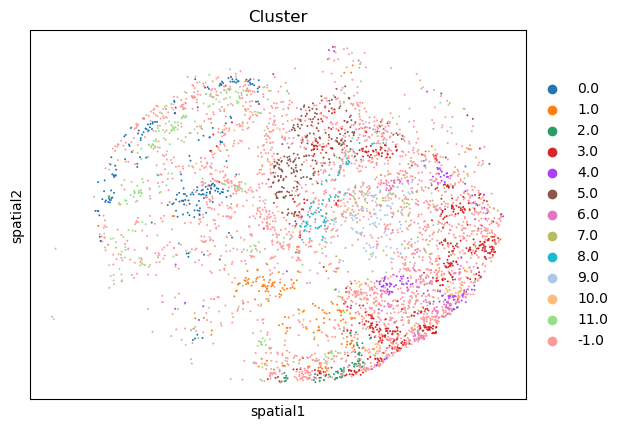

In [107]:
sc.pl.embedding(lrdata, basis="spatial", color="Cluster", s=8)  # s = point size

# Regression Model

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [110]:
#get variables 
factors = model.get_factors() 
F = factors["group_1"]

#Get dependent var, change typ to any metadata column you wish to predict if factor values can predict
cell_names = F.index
cell_types = lrdata.obs["cell_type_lv1"]

#Sort both
cell_types = cell_types.sort_index()
F=  F.sort_index()

#Filter out any datapoint in response var that is not in features
filtered_cell_types = cell_types.loc[cell_types.index.isin(cell_names)]

### Create X and Y objects

In [111]:
F

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10
AAACCCAAGACAGCTG-1,0.089297,0.156648,0.198385,0.115699,-0.069015,-0.006137,0.034704,0.185683,0.193663,-0.185691
AAACCCACACACGGAA-1,-0.340657,-0.207949,-0.177231,0.469493,-0.023081,0.002617,-0.742282,0.061500,-0.227804,0.620112
AAACCCACAGGTTCCG-1,-0.845567,0.103709,0.925108,-1.614292,1.864745,0.649764,-0.117423,-1.162067,0.342459,-1.494942
AAACGAAAGAATTCAG-1,-1.086392,-0.244970,1.526157,1.317872,0.998287,-2.290566,-1.954477,1.028862,-0.209252,0.352227
AAACGAAAGCTATCTG-1,-0.239550,0.062554,-0.429245,0.058319,0.208186,0.055306,0.006106,-0.097116,-0.064159,0.113589
...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTCAAAGAT-1,0.056015,-0.269220,-0.996007,0.101901,0.659808,0.118846,0.113697,0.802752,0.870275,-0.938725
TTTGGTTGTTCCAGGC-1,0.885309,-0.102733,0.648152,-0.639287,-0.849772,-0.735614,-0.165376,-0.352646,-0.518873,0.003250
TTTGTTGCAAGGTTGG-1,-0.539255,0.207665,-0.384455,0.353973,-0.333315,-0.042340,-1.019749,0.311199,-0.039616,0.641904
TTTGTTGCAGAGATGC-1,-0.277460,-0.325571,-0.298844,0.169383,-0.483521,0.067550,-0.050833,0.341962,-0.232866,0.386090


In [112]:
filtered_cell_types

AAACCCAAGACAGCTG-1          Glial
AAACCCACACACGGAA-1          Glial
AAACCCACAGGTTCCG-1          Glial
AAACGAAAGAATTCAG-1    Endothelial
AAACGAAAGCTATCTG-1         Neuron
                         ...     
TTTGGTTGTCAAAGAT-1         Neuron
TTTGGTTGTTCCAGGC-1         Neuron
TTTGTTGCAAGGTTGG-1         Neuron
TTTGTTGCAGAGATGC-1         Neuron
TTTGTTGGTGCGGCTT-1         Neuron
Name: cell_type_lv1, Length: 4584, dtype: category
Categories (6, object): ['Choroid Plexus', 'Endothelial', 'Fibroblast', 'Glial', 'Immune', 'Neuron']

In [113]:
X = F.values
y = filtered_cell_types.values  # labels

In [114]:
#Drop NaN labels
mask = ~pd.isna(y)
X = X[mask]
y = y[mask]

In [115]:
print(X.shape, y.shape)

(4584, 10) (4584,)


In [116]:
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Median:", np.median(X))
print("Std dev:", np.std(X))

Min: -3.5166674
Max: 3.334042
Mean: -0.020381292
Median: -0.011735693
Std dev: 0.5821222


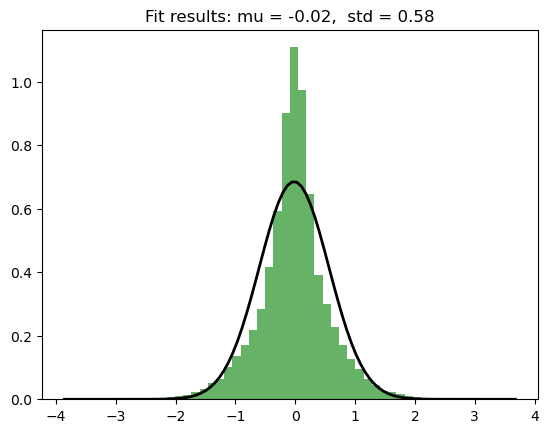

In [117]:
from scipy.stats import norm

data = X.flatten()

# histogram
plt.hist(data, bins=50, density=True, alpha=0.6, color='g')

# fit a normal
mu, std = norm.fit(data)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

plt.title(f"Fit results: mu = {mu:.2f},  std = {std:.2f}")
plt.show()


### Train multinomial logistic regression

In [118]:
# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [119]:
clf = LogisticRegression(
    solver="lbfgs",
    max_iter=200,
    class_weight="balanced"
)

In [120]:
clf.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

### Evaluate the model

In [121]:
# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5661337209302325

Classification Report:
                 precision    recall  f1-score   support

Choroid Plexus       0.04      0.53      0.08        15
   Endothelial       0.10      0.52      0.17        23
    Fibroblast       0.22      0.56      0.32        64
         Glial       0.57      0.61      0.59       164
        Immune       0.03      0.27      0.06        11
        Neuron       0.96      0.56      0.71      1099

      accuracy                           0.57      1376
     macro avg       0.32      0.51      0.32      1376
  weighted avg       0.85      0.57      0.66      1376



### AUC

In [122]:
from sklearn.metrics import roc_auc_score, roc_curve

#### 1. If threr are 2 classes only (REF vs. CRC)

AUC: 0.6078538535729829


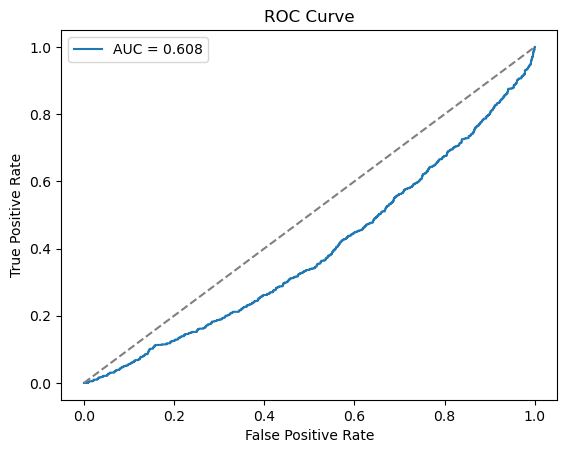

In [87]:
# Get predicted probabilities for the positive class (assume label "232_REF" is positive)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

# Calculate AUC
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label="222_REF")
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#### 2. If classes are more than 2:

In [123]:
# Get class probabilities 
y_proba = clf.predict_proba(X_test)   # shape = (n_samples, 3)

# Compute macro-average AUC (each class equally weighted, good default)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Multiclass ROC AUC (OvR, macro): {auc_macro:.4f}")

# You could also try weighted averaging (weights by class support):
auc_weighted = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
print(f"Multiclass ROC AUC (OvR, weighted): {auc_weighted:.4f}")


Multiclass ROC AUC (OvR, macro): 0.8206
Multiclass ROC AUC (OvR, weighted): 0.8602


# Map clusters to spatial 

In [124]:
df_umap

,UMAP1,UMAP2,Cluster,Conf,Label
AAACGAACAGAGAGGG-1,13.061376,5.410181,-1,0.0,Immune
AAAGAACGTGGCCTCA-1,10.871474,1.492406,-1,0.0,Choroid Plexus
AAAGGTATCCAATGCA-1,13.442327,5.513301,-1,0.0,Neuron
AACAGGGCAAAGGTTA-1,12.935088,5.670247,-1,0.0,Neuron
AACCTTTCAGAGTTCT-1,12.218725,7.444514,-1,0.0,Choroid Plexus
...,...,...,...,...,...
TTTCACAGTCAAAGCG-1,9.054873,5.679649,-1,0.0,Immune
TTTCAGTGTACACGCC-1,12.211121,5.844440,-1,0.0,Immune
TTTCGATAGCCATGCC-1,10.836908,5.965825,-1,0.0,Fibroblast
TTTGGAGAGCCAACCC-1,11.973813,2.888310,-1,0.0,Neuron


In [125]:
clusters = df_umap['Cluster'].reindex(lrdata.obs_names)
print(f"Missing cluster labels: {clusters.isna().sum()}")

Missing cluster labels: 39


In [126]:
lrdata.obs['Cluster'] = clusters.astype('category')

/scratch/jobs/38194466/ipykernel_1239780/1180120996.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


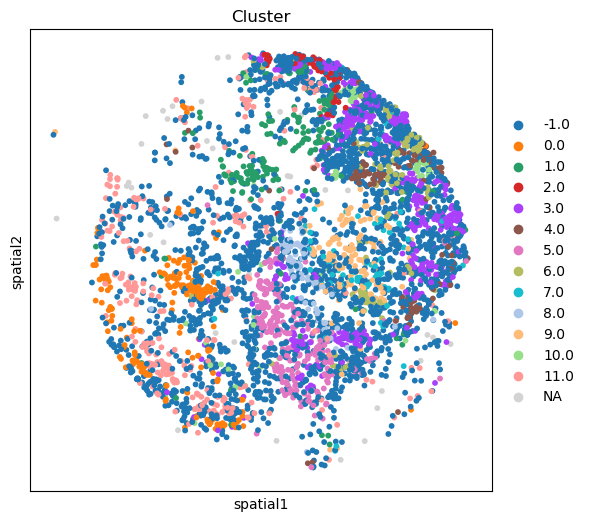

In [127]:
fig, axes = plt.subplots(1, 1, figsize=(6, 6))
sc.pl.spatial(
    lrdata,
    color='Cluster',
    spot_size=40,
    ax=axes
)
plt.tight_layout()